# Lab 01 — Chương 1: Overview & Anscombe (Solution)

**Mục tiêu:** tái hiện Anscombe’s Quartet và nêu bài học về việc không chỉ dựa vào summary statistics.

**Đọc:** `related/english/chapter1.tex`


## Setup

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


## Task 1 — Anscombe: summary stats vs scatter

In [2]:
df = sns.load_dataset("anscombe")
df.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


In [3]:
# Summary statistics per dataset
summary = (
    df.groupby("dataset")
    .agg(
        x_mean=("x", "mean"),
        y_mean=("y", "mean"),
        x_var=("x", "var"),
        y_var=("y", "var"),
        corr=("x", lambda s: s.corr(df.loc[s.index, "y"])),
    )
    .round(3)
)
summary

,x_mean,y_mean,x_var,y_var,corr
dataset,,,,,
I,9.0,7.501,11.0,4.127,0.816
II,9.0,7.501,11.0,4.128,0.816
III,9.0,7.500,11.0,4.123,0.816
IV,9.0,7.501,11.0,4.123,0.817


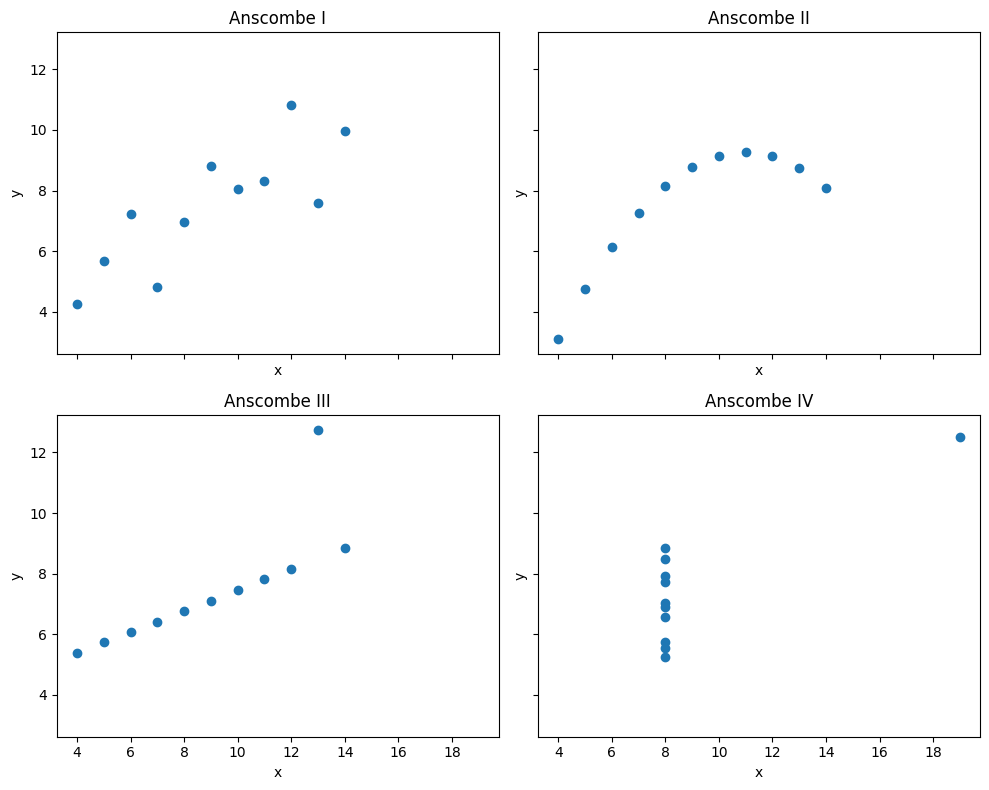

In [4]:
# Scatter 2x2
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, (name, g) in zip(axes, df.groupby("dataset"), strict=True):
    ax.scatter(g["x"], g["y"])
    ax.set_title(f"Anscombe {name}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## Task 2 — SciViz vs InfoViz (minh họa đơn giản)

Để minh họa *góc nhìn*:
- **Information viz**: cùng dữ liệu, tập trung “so sánh/quan hệ” → scatter.
- **Scientific-ish viz**: cùng dữ liệu, ép về “field”/“bề mặt” (minh họa) → ước lượng mật độ 2D.

Lưu ý: đây chỉ là minh họa ý niệm, không khẳng định Anscombe là SciViz.


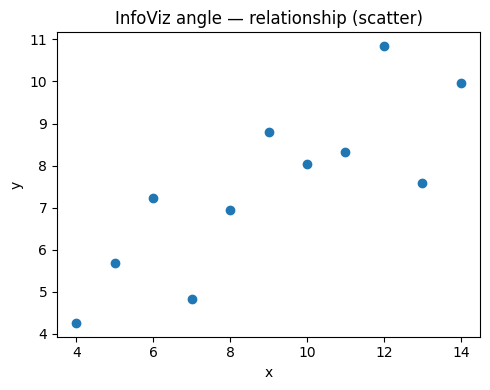

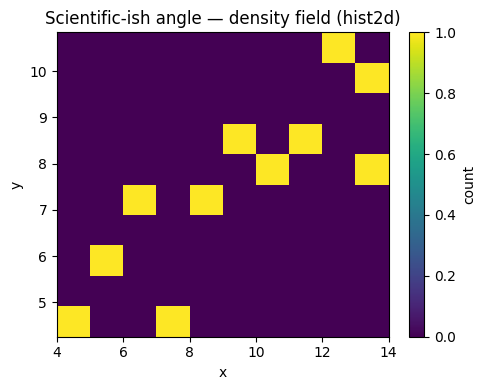

In [5]:
import numpy as np

g = df[df["dataset"] == "I"].copy()

# InfoViz: scatter (relationship)
plt.figure(figsize=(5, 4))
plt.scatter(g["x"], g["y"])
plt.title("InfoViz angle — relationship (scatter)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Scientific-ish angle: 2D density (field-like view)
plt.figure(figsize=(5, 4))
plt.hist2d(g["x"], g["y"], bins=(10, 10), cmap="viridis")
plt.colorbar(label="count")
plt.title("Scientific-ish angle — density field (hist2d)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

## Reflection (mẫu)

- **Ba chức năng DV:** (1) ghi nhận, (2) phân tích/hình thành giả thuyết, (3) truyền thông.
  Trong bài này, Anscombe nhấn mạnh (2): dùng hình để *kiểm tra giả định* trước khi kết luận.
- **Bài học Anscombe:** 4 bộ có thống kê gần giống nhưng cấu trúc khác nhau → nếu chỉ nhìn mean/var/corr sẽ dễ kết luận sai.

**Họ tên / MSSV:** (điền khi chấm)
